# Analyse bivariée de variables qualitatives et test du chi-2
Ici est présenté une analyse bivariée de variables qualitatives dans le but d'analyser la relation entre le lieu d'origine, l'année de naissance, ainsi que le genre des individus de la population d'étude. Nous procéderons à un test du chi-2 afin de déterminer s'il existe une association statistiquement significative entre les différentes variables dans le temps. Ainsi, nous tentons d'observer de quelle manière la distribution géogrpahique de la population évolue dans le temps, et s'il y a une sur-représentation de femmes sociologues dans certaines régions.

In [4]:
import pandas as pd

import scipy.stats as stats
import statsmodels.api as sm

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import numpy as np
import seaborn as sns

In [5]:
import pprint
import csv
import sys

import time
import datetime
from dateutil import parser
from shutil import copyfile

In [6]:
import warnings
warnings.filterwarnings('ignore')

# Création d'une dataframe à partir des données à analyser
Nous utliserons ici les données produites précédemment (cf. da2), c'est-à-dire une liste des individus avec leur années de naissance, leur genre, leur lieu de naissance, ainsi qu'à quelle région du monde leur lieu naissance correspond.

In [7]:
csv_address='data_analysis/da3-birthYear-gender-region.csv'
df_p = pd.read_csv(csv_address)
df_p.head()

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION
0,http://www.wikidata.org/entity/Q1685927,Jean-Guillaume-César-Alexandre-Hippolyte Colins,1783,male,Brussels metropolitan area,POINT (4.3525 50.846667),http://www.wikidata.org/entity/Q9005,1781-1790,22,Western Europe
1,http://www.wikidata.org/entity/Q20012,Adolphe Quetelet,1796,male,Ghent,POINT (3.725278 51.053611),http://www.wikidata.org/entity/Q1296,1791-1800,22,Western Europe
2,http://www.wikidata.org/entity/Q1708975,José Antonio Saco,1797,male,Bayamo,POINT (-76.642778 20.381667),http://www.wikidata.org/entity/Q115382,1791-1800,3,Caribbean
3,http://www.wikidata.org/entity/Q973094,Ramón de la Sagra,1798,male,A Coruña,POINT (-8.400027 43.373857),http://www.wikidata.org/entity/Q8757,1791-1800,19,Southern Europe
4,http://www.wikidata.org/entity/Q957065,Henry Charles Carey,1793,male,Philadelphia,POINT (-75.163611 39.952778),http://www.wikidata.org/entity/Q1345,1791-1800,23,Northern America


In [8]:
### Inspect the dataframe and 
# notably if there are missing values
df_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9912 entries, 0 to 9911
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   uriPer      9912 non-null   object
 1   labelPer    9646 non-null   object
 2   birthYear   9912 non-null   int64 
 3   gender      9873 non-null   object
 4   labelPlace  9912 non-null   object
 5   geometry    9912 non-null   object
 6   uriPlace    9912 non-null   object
 7   periods     9494 non-null   object
 8   FID         9912 non-null   int64 
 9   REGION      9912 non-null   object
dtypes: int64(2), object(8)
memory usage: 774.5+ KB


# Vérifier la variable : genre

In [9]:
### Group and count
# We observe some dispersion that requires grouping the categories of the variable
df_gender = df_p.groupby('gender').size()
df_gender = pd.DataFrame(df_gender.sort_values(ascending = False))
df_gender.columns=['number']
print(df_gender)

                    number
gender                    
male                  7430
female                2430
trans woman              7
trans man                2
non-binary               2
genderqueer              1
undisclosed gender       1


# Distribution des régions de naissance

In [10]:
### Group and count
# We observe some dispersion that requires grouping the categories of the variable
df_country = df_p.groupby('REGION').size()
df_country = pd.DataFrame(df_country.sort_values(ascending = False))
df_country.columns=['number']
print(df_country.iloc[:50])
#print(df_country[(df_country.number < 21) & (df_country.number >5)])

                       number
REGION                       
Western Europe           2865
Eastern Europe           1880
Southern Europe          1336
Northern America         1021
South America             678
Northern Europe           498
Eastern Asia              474
European Russia           282
Western Asia              202
Southern Asia             155
Northern Africa           112
Central America           108
Asiatic Russia             50
Australia/New Zealand      49
Western Africa             45
Caribbean                  44
Southeastern Asia          34
Middle Africa              24
Southern Africa            21
Central Asia               20
Eastern Africa             14


In [11]:
### Example of values
print(len(df_p[df_p.REGION=='Western Europe']))
df_p[df_p.REGION=='Western Europe'].head(3)

2865


,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION
0,http://www.wikidata.org/entity/Q1685927,Jean-Guillaume-César-Alexandre-Hippolyte Colins,1783,male,Brussels metropolitan area,POINT (4.3525 50.846667),http://www.wikidata.org/entity/Q9005,1781-1790,22,Western Europe
1,http://www.wikidata.org/entity/Q20012,Adolphe Quetelet,1796,male,Ghent,POINT (3.725278 51.053611),http://www.wikidata.org/entity/Q1296,1791-1800,22,Western Europe
5,http://www.wikidata.org/entity/Q577445,Philippe Buchez,1796,male,Matagne-la-Petite,POINT (4.6469 50.1189),http://www.wikidata.org/entity/Q2240362,1791-1800,22,Western Europe


In [12]:
### countries with more than 200 persons
df_country_200 = df_country[df_country.number > 200]
print(len(df_country_200))

9


In [13]:
df_country_200

,number
REGION,
Western Europe,2865
Eastern Europe,1880
Southern Europe,1336
Northern America,1021
South America,678
Northern Europe,498
Eastern Asia,474
European Russia,282
Western Asia,202


In [14]:
lc200=df_country_200.index.to_list()
lc200

['Western Europe',
 'Eastern Europe',
 'Southern Europe',
 'Northern America',
 'South America',
 'Northern Europe',
 'Eastern Asia',
 'European Russia',
 'Western Asia']

## Tranformer les années de naissance en périodes d'activités

In [19]:
### Create imputed activity year
df_p['activityYear'] = df_p.birthYear.apply(lambda x : int(x)+45)

In [17]:
df_p = df_p.drop(['activityYear'], axis=1)

In [20]:
### Create list of 25 years periods

yr = df_p.activityYear

l_25 = list(range(min(yr), max(yr)+ 25, 25))
print(l_25[:5],l_25[-5:], len(l_25)-1)

[1828, 1853, 1878, 1903, 1928] [1953, 1978, 2003, 2028, 2053] 9


In [21]:
### fonction pd.cut : https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.cut.html
# A new column is added containing the period, based on the previous list and the year value

df_p['periodsActivity'] = pd.cut(df_p['activityYear'], l_25, right=False)

### Rewrite the added code to make it more readable
df_p['periodsActivity'] = df_p['periodsActivity'].apply(lambda x : str(int(x.left))+'-'+ str(int(x.right)-1))

In [22]:
# Inspection
df_p.head(3)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,activityYear,periodsActivity
0,http://www.wikidata.org/entity/Q1685927,Jean-Guillaume-César-Alexandre-Hippolyte Colins,1783,male,Brussels metropolitan area,POINT (4.3525 50.846667),http://www.wikidata.org/entity/Q9005,1781-1790,22,Western Europe,1828,1828-1852
1,http://www.wikidata.org/entity/Q20012,Adolphe Quetelet,1796,male,Ghent,POINT (3.725278 51.053611),http://www.wikidata.org/entity/Q1296,1791-1800,22,Western Europe,1841,1828-1852
2,http://www.wikidata.org/entity/Q1708975,José Antonio Saco,1797,male,Bayamo,POINT (-76.642778 20.381667),http://www.wikidata.org/entity/Q115382,1791-1800,3,Caribbean,1842,1828-1852


In [23]:
### Distribution of activities by 25 years periods
activities_per = pd.DataFrame(df_p.groupby(by='periodsActivity').size())
activities_per.columns=['number']
print(activities_per)

                 number
periodsActivity        
1828-1852            17
1853-1877            52
1878-1902           148
1903-1927           373
1928-1952           668
1953-1977          1628
1978-2002          4204
2003-2027          2529
2028-2052           293


## Préparation des données pour l'analyse factorielle de correspondances cf. da4

In [26]:
file_address='data_analysis/da4_CA.csv'
df_p.to_csv(file_address, index=False)

# Analyse bivariée des pays et des périodes d'activités

In [29]:
### Contingency table: 
# count how many individuals exhibit both of these categories for each of the two variables 
per_vs_country=pd.crosstab(df_p.periodsActivity, df_p.REGION, margins=True)

## display all columns
pd.set_option('display.max_columns', None)

per_vs_country.iloc[2:]

REGION,Asiatic Russia,Australia/New Zealand,Caribbean,Central America,Central Asia,Eastern Africa,Eastern Asia,Eastern Europe,European Russia,Middle Africa,Northern Africa,Northern America,Northern Europe,South America,Southeastern Asia,Southern Africa,Southern Asia,Southern Europe,Western Africa,Western Asia,Western Europe,All
periodsActivity,,,,,,,,,,,,,,,,,,,,,,
1878-1902,1,0,1,0,0,0,2,28,11,0,0,12,8,11,0,1,0,26,0,0,47,148
1903-1927,0,1,0,2,0,0,5,94,5,0,1,69,25,15,0,0,3,46,0,3,104,373
1928-1952,2,2,4,12,1,0,35,149,22,0,3,123,19,26,2,1,10,41,0,4,212,668
1953-1977,6,3,7,8,2,1,67,371,47,1,18,294,79,85,9,6,30,138,2,28,426,1628
1978-2002,28,24,26,50,8,7,212,690,118,13,74,408,248,328,14,11,63,555,28,95,1204,4204
2003-2027,13,17,2,32,9,5,142,469,65,10,16,100,99,187,8,1,46,472,13,68,755,2529
2028-2052,0,2,2,4,0,1,11,73,6,0,0,10,12,26,1,1,3,52,2,4,83,293
All,50,49,44,108,20,14,474,1880,282,24,112,1021,498,678,34,21,155,1336,45,202,2865,9912


In [30]:
observed = per_vs_country.iloc[2:-1, :-1 ]
observed

REGION,Asiatic Russia,Australia/New Zealand,Caribbean,Central America,Central Asia,Eastern Africa,Eastern Asia,Eastern Europe,European Russia,Middle Africa,Northern Africa,Northern America,Northern Europe,South America,Southeastern Asia,Southern Africa,Southern Asia,Southern Europe,Western Africa,Western Asia,Western Europe
periodsActivity,,,,,,,,,,,,,,,,,,,,,
1878-1902,1,0,1,0,0,0,2,28,11,0,0,12,8,11,0,1,0,26,0,0,47
1903-1927,0,1,0,2,0,0,5,94,5,0,1,69,25,15,0,0,3,46,0,3,104
1928-1952,2,2,4,12,1,0,35,149,22,0,3,123,19,26,2,1,10,41,0,4,212
1953-1977,6,3,7,8,2,1,67,371,47,1,18,294,79,85,9,6,30,138,2,28,426
1978-2002,28,24,26,50,8,7,212,690,118,13,74,408,248,328,14,11,63,555,28,95,1204
2003-2027,13,17,2,32,9,5,142,469,65,10,16,100,99,187,8,1,46,472,13,68,755
2028-2052,0,2,2,4,0,1,11,73,6,0,0,10,12,26,1,1,3,52,2,4,83


In [31]:
### Calculation of parameters for the chi-square test
statistic, p, dof, expected = stats.chi2_contingency(observed)

In [32]:
dfe=pd.DataFrame(expected.round(0))
dfe.columns=observed.columns
dfe.index=observed.index
dfe

REGION,Asiatic Russia,Australia/New Zealand,Caribbean,Central America,Central Asia,Eastern Africa,Eastern Asia,Eastern Europe,European Russia,Middle Africa,Northern Africa,Northern America,Northern Europe,South America,Southeastern Asia,Southern Africa,Southern Asia,Southern Europe,Western Africa,Western Asia,Western Europe
periodsActivity,,,,,,,,,,,,,,,,,,,,,
1878-1902,1.0,1.0,1.0,2.0,0.0,0.0,7.0,28.0,4.0,0.0,2.0,15.0,7.0,10.0,1.0,0.0,2.0,20.0,1.0,3.0,43.0
1903-1927,2.0,2.0,2.0,4.0,1.0,1.0,18.0,71.0,10.0,1.0,4.0,39.0,19.0,26.0,1.0,1.0,6.0,50.0,2.0,8.0,107.0
1928-1952,3.0,3.0,3.0,7.0,1.0,1.0,32.0,127.0,19.0,2.0,8.0,69.0,33.0,46.0,2.0,1.0,11.0,90.0,3.0,14.0,192.0
1953-1977,8.0,8.0,7.0,18.0,3.0,2.0,78.0,310.0,45.0,4.0,19.0,168.0,81.0,112.0,6.0,3.0,26.0,220.0,7.0,33.0,468.0
1978-2002,21.0,21.0,18.0,46.0,9.0,6.0,202.0,800.0,117.0,10.0,48.0,434.0,209.0,290.0,15.0,9.0,66.0,568.0,19.0,86.0,1209.0
2003-2027,13.0,13.0,11.0,28.0,5.0,4.0,122.0,481.0,70.0,6.0,29.0,261.0,126.0,174.0,9.0,5.0,40.0,342.0,12.0,52.0,727.0
2028-2052,1.0,1.0,1.0,3.0,1.0,0.0,14.0,56.0,8.0,1.0,3.0,30.0,15.0,20.0,1.0,1.0,5.0,40.0,1.0,6.0,84.0


In [33]:
## Degrees of freedom and Chi-square

print('Degrees of freedom:', dof, '; Chi-square value:', statistic.round(2))

Degrees of freedom: 120 ; Chi-square value: 666.62


In [34]:
### P-value
print('p-value :', p)

p-value : 1.0867912643094217e-76


In [35]:
### Cramér's V (normalized phi) coefficient
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html
vc = stats.contingency.association(observed, method='cramer')
print('Cramèr\'s V:', vc)

Cramèr's V: 0.10624263045105352


In [36]:
### Get signed resitduals using statmodels (sm)

# 1. Create the Table object directly from your data
table = sm.stats.Table(observed)

# 2. Get Adjusted Residuals instantly (no manual formula needed)
adjusted_resids = table.standardized_resids
adjusted_resids.round(1)

REGION,Asiatic Russia,Australia/New Zealand,Caribbean,Central America,Central Asia,Eastern Africa,Eastern Asia,Eastern Europe,European Russia,Middle Africa,Northern Africa,Northern America,Northern Europe,South America,Southeastern Asia,Southern Africa,Southern Asia,Southern Europe,Western Africa,Western Asia,Western Europe
periodsActivity,,,,,,,,,,,,,,,,,,,,,
1878-1902,0.2,-0.3,0.4,-0.9,0.3,0.5,-2.0,-0.2,3.3,0.2,-1.0,-1.0,0.1,0.2,-0.1,1.2,-1.3,1.3,-0.3,-1.5,0.5
1903-1927,-1.1,-0.7,-0.9,-1.1,-0.4,-0.1,-3.2,3.0,-1.8,-0.5,-1.6,5.2,1.5,-2.3,-0.7,-0.4,-1.2,-0.7,-1.0,-1.8,-0.5
1928-1952,-0.8,-0.8,0.7,1.8,-0.4,-0.6,0.5,2.2,0.8,-1.0,-1.8,7.1,-2.6,-3.2,-0.3,-0.4,-0.2,-5.8,-1.6,-2.8,1.7
1953-1977,-0.9,-2.0,-0.0,-2.6,-0.9,-1.1,-1.4,4.2,0.3,-1.7,-0.2,11.3,-0.2,-2.9,1.5,1.4,0.9,-6.5,-2.2,-1.0,-2.5
1978-2002,1.8,0.8,2.4,0.7,-0.5,0.2,0.9,-5.7,0.1,0.8,4.9,-1.7,3.7,3.1,-0.3,0.8,-0.5,-0.7,2.4,1.2,-0.2
2003-2027,-0.0,1.4,-3.1,0.9,1.7,0.6,2.2,-0.7,-0.7,1.5,-2.8,-12.2,-2.8,1.2,-0.4,-2.2,1.1,8.8,0.4,2.6,1.5
2028-2052,-0.8,0.4,0.7,0.4,-0.2,0.8,-0.9,2.5,-0.8,-0.3,-1.6,-4.0,-0.7,1.3,-0.0,0.5,-0.8,2.1,0.5,-0.9,-0.2


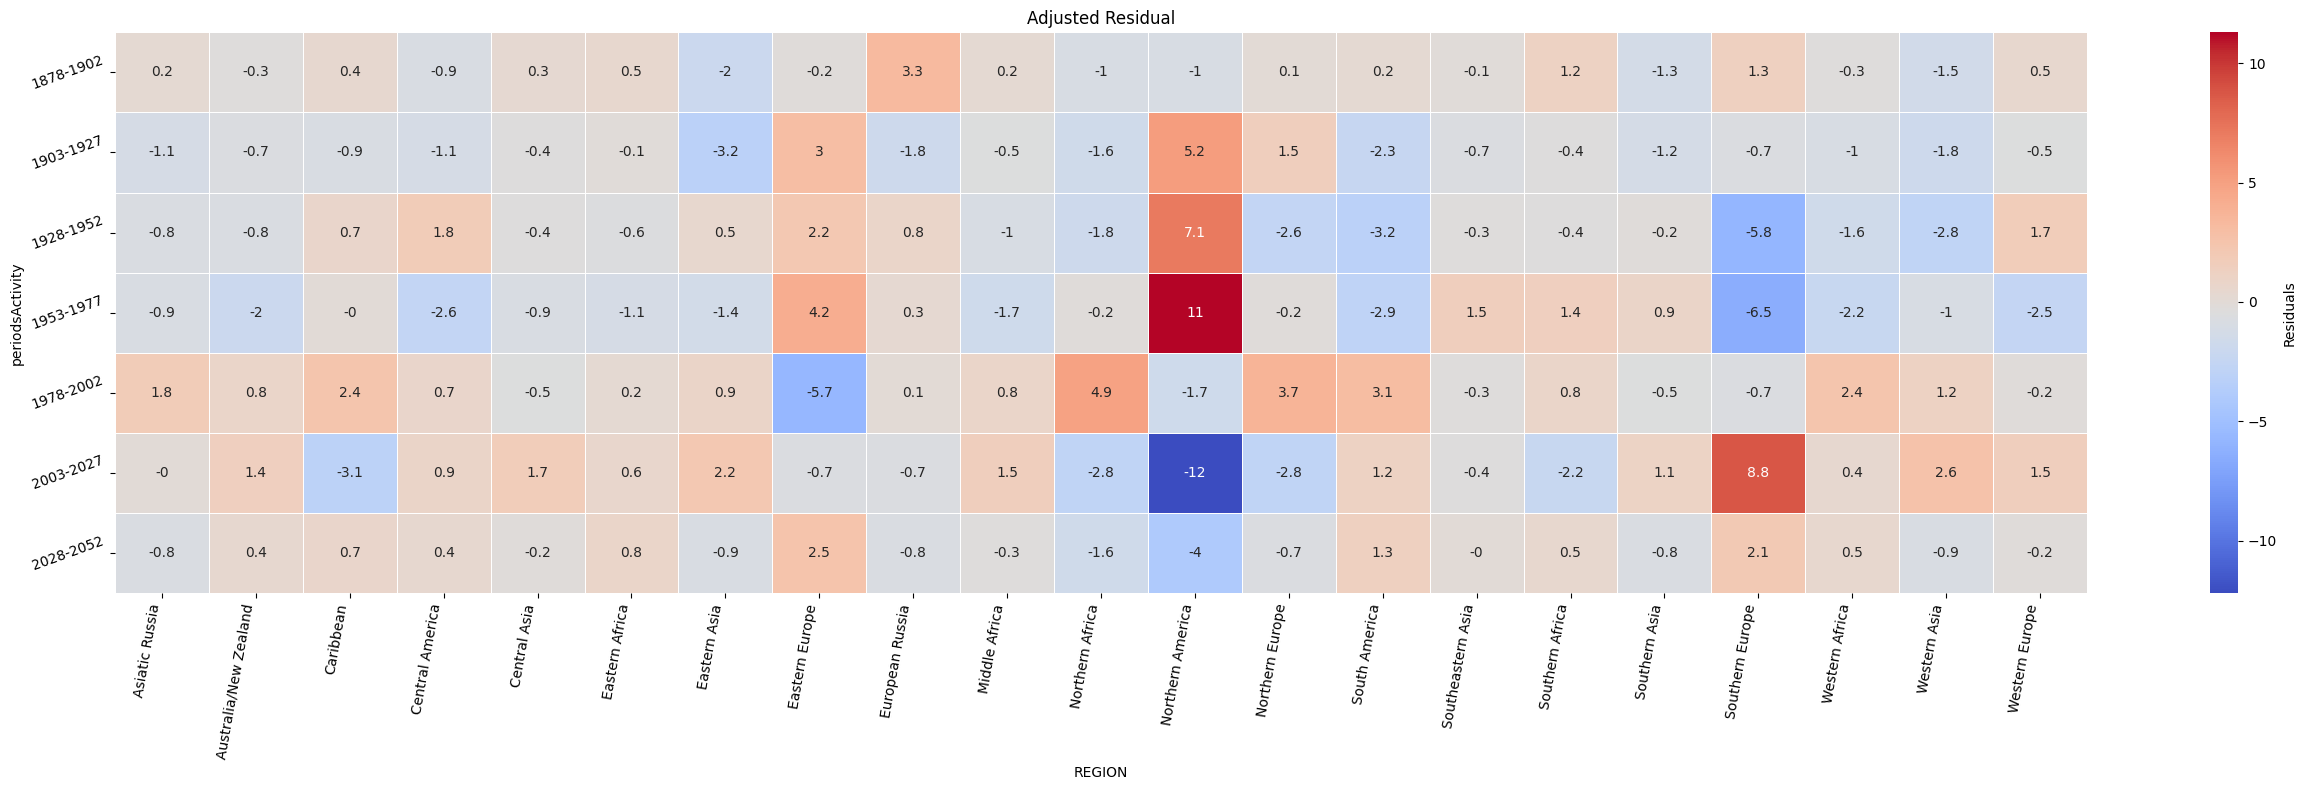

In [37]:
### Plot the residuals

# 3. Plot
fig, ax = plt.subplots(1,1,figsize=(26,8))         


# Create heatmap
sns.heatmap(
    adjusted_resids.round(1), 
    annot=True,            # Use boolean True to annotate with data values
    cmap="coolwarm", 
    linewidths=.5, 
    ax=ax,
    cbar_kws={'label': 'Residuals'}
)
# 3. Fix Label Rotation (Safe Method)
# This rotates existing ticks without risking a count mismatch
ax.set_xticklabels(ax.get_xticklabels(), rotation=80, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=20, va='center')
ax.set_title("Adjusted Residual", fontsize=12)

# ax.set_title("Heatmap of Adjusted Residuals (via statsmodels)")
plt.tight_layout()
plt.show()

In [38]:
## Compare with number
per_vs_country.iloc[2:]

REGION,Asiatic Russia,Australia/New Zealand,Caribbean,Central America,Central Asia,Eastern Africa,Eastern Asia,Eastern Europe,European Russia,Middle Africa,Northern Africa,Northern America,Northern Europe,South America,Southeastern Asia,Southern Africa,Southern Asia,Southern Europe,Western Africa,Western Asia,Western Europe,All
periodsActivity,,,,,,,,,,,,,,,,,,,,,,
1878-1902,1,0,1,0,0,0,2,28,11,0,0,12,8,11,0,1,0,26,0,0,47,148
1903-1927,0,1,0,2,0,0,5,94,5,0,1,69,25,15,0,0,3,46,0,3,104,373
1928-1952,2,2,4,12,1,0,35,149,22,0,3,123,19,26,2,1,10,41,0,4,212,668
1953-1977,6,3,7,8,2,1,67,371,47,1,18,294,79,85,9,6,30,138,2,28,426,1628
1978-2002,28,24,26,50,8,7,212,690,118,13,74,408,248,328,14,11,63,555,28,95,1204,4204
2003-2027,13,17,2,32,9,5,142,469,65,10,16,100,99,187,8,1,46,472,13,68,755,2529
2028-2052,0,2,2,4,0,1,11,73,6,0,0,10,12,26,1,1,3,52,2,4,83,293
All,50,49,44,108,20,14,474,1880,282,24,112,1021,498,678,34,21,155,1336,45,202,2865,9912


# Analyse bivariée du genre

In [40]:
gender_vs_country=pd.crosstab(df_p.gender, df_p.REGION, margins=True)
gender_vs_country

REGION,Asiatic Russia,Australia/New Zealand,Caribbean,Central America,Central Asia,Eastern Africa,Eastern Asia,Eastern Europe,European Russia,Middle Africa,Northern Africa,Northern America,Northern Europe,South America,Southeastern Asia,Southern Africa,Southern Asia,Southern Europe,Western Africa,Western Asia,Western Europe,All
gender,,,,,,,,,,,,,,,,,,,,,,
female,18,17,12,44,5,4,66,457,51,4,29,229,131,241,12,4,31,348,14,61,652,2430
genderqueer,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1
male,32,27,32,63,13,10,388,1423,230,20,83,787,365,434,21,17,123,981,31,141,2209,7430
non-binary,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,2
trans man,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,2
trans woman,0,3,0,0,0,0,0,0,0,0,0,1,1,2,0,0,0,0,0,0,0,7
undisclosed gender,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
All,50,48,44,108,18,14,454,1880,281,24,112,1019,497,677,33,21,154,1330,45,202,2862,9873


In [41]:
### Take the margins away
observed = gender_vs_country.iloc[:-1, :-1 ]
### Calcul des paramètres pour le test du Chi-2
statistic, p, dof, expected = stats.chi2_contingency(observed)
print('Chi2 :', statistic, ', dof :',dof)
print('p-value :', p)

Chi2 : 655.2826971815341 , dof : 120
p-value : 1.146949677745408e-74


In [42]:
### Cramér's phi coefficient
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html
vc = stats.contingency.association(observed, method='cramer')
print('Cramèr\'s V:', vc)

Cramèr's V: 0.10517539616580271


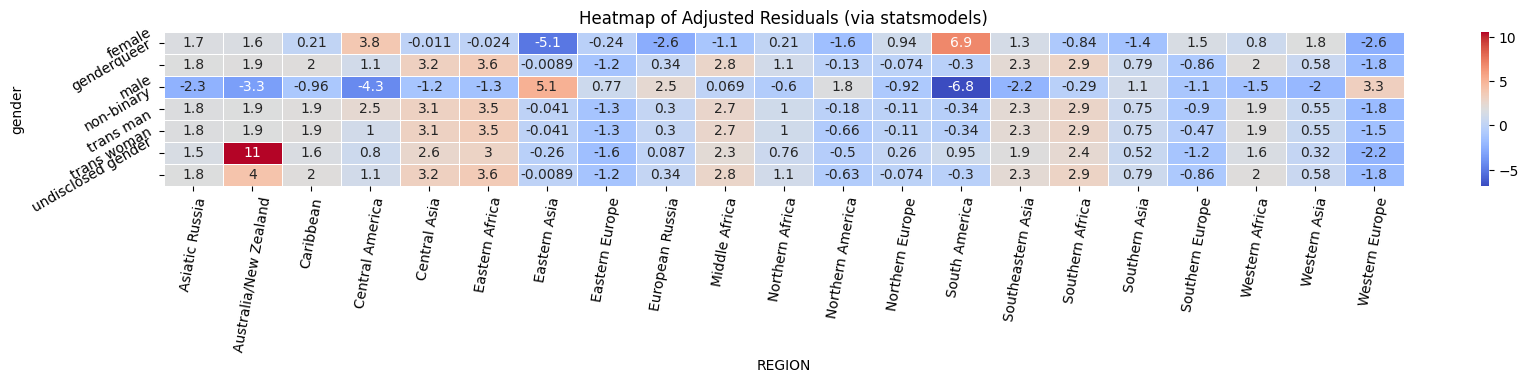

In [43]:
# 1. Create the Table object directly from your data
table = sm.stats.Table(observed)

# 2. Get Adjusted Residuals instantly (no manual formula needed)
adjusted_resids = table.standardized_resids
# 3. Plot
fig, ax = plt.subplots(figsize=(20,2))         
# Sample figsize in inches
ax = sns.heatmap(adjusted_resids, annot=adjusted_resids, cmap="coolwarm", linewidths=.5, ax=ax)
labels = adjusted_resids.index
p = ax.set_yticklabels(labels, rotation=30)
labels_cols = adjusted_resids.columns
p = ax.set_xticklabels(labels_cols, rotation=80)

ax.set_title("Heatmap of Adjusted Residuals (via statsmodels)")
plt.show()

# Analyse bivariée du genre et des générations par rapport aux régions

In [44]:
def code_gender_period(gender: str):
    if gender == 'female':
        output='f'
    else:
        output='m'
    return output   

In [45]:
df_p['per_gender']= df_p.apply(lambda x: x.periodsActivity +'_'+ code_gender_period(x.gender), axis=1)
df_p.head(2)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,activityYear,periodsActivity,per_gender
0,http://www.wikidata.org/entity/Q1685927,Jean-Guillaume-César-Alexandre-Hippolyte Colins,1783,male,Brussels metropolitan area,POINT (4.3525 50.846667),http://www.wikidata.org/entity/Q9005,1781-1790,22,Western Europe,1828,1828-1852,1828-1852_m
1,http://www.wikidata.org/entity/Q20012,Adolphe Quetelet,1796,male,Ghent,POINT (3.725278 51.053611),http://www.wikidata.org/entity/Q1296,1791-1800,22,Western Europe,1841,1828-1852,1828-1852_m


In [47]:
per_gender_vs_country=pd.crosstab(df_p.per_gender, df_p.REGION, margins=True)
per_gender_vs_country.iloc[6:]

REGION,Asiatic Russia,Australia/New Zealand,Caribbean,Central America,Central Asia,Eastern Africa,Eastern Asia,Eastern Europe,European Russia,Middle Africa,Northern Africa,Northern America,Northern Europe,South America,Southeastern Asia,Southern Africa,Southern Asia,Southern Europe,Western Africa,Western Asia,Western Europe,All
per_gender,,,,,,,,,,,,,,,,,,,,,,
1903-1927_f,0,0,0,0,0,0,0,3,1,0,0,15,4,0,0,0,1,1,0,0,10,35
1903-1927_m,0,1,0,2,0,0,5,91,4,0,1,54,21,15,0,0,2,45,0,3,94,338
1928-1952_f,1,1,0,5,0,0,1,9,0,0,1,23,5,4,0,0,0,3,0,0,25,78
1928-1952_m,1,1,4,7,1,0,34,140,22,0,2,100,14,22,2,1,10,38,0,4,187,590
1953-1977_f,1,1,0,2,1,0,2,53,6,0,6,41,11,20,2,1,2,10,0,7,74,240
1953-1977_m,5,2,7,6,1,1,65,318,41,1,12,253,68,65,7,5,28,128,2,21,352,1388
1978-2002_f,10,7,10,21,2,2,30,172,21,2,15,100,62,125,6,2,13,121,9,26,227,983
1978-2002_m,18,17,16,29,6,5,182,518,97,11,59,308,186,203,8,9,50,434,19,69,977,3221
2003-2027_f,6,6,1,15,2,2,30,176,19,2,7,40,43,79,3,0,15,180,4,25,271,926


In [48]:
### Only mor recent periods
observed = per_gender_vs_country.iloc[6:-1, :-1 ]

In [49]:
### For significant chi-2 test minimal number in each cell of expected:5
# bias in the results
statistic, p, dof, expected = stats.chi2_contingency(observed)
dfe = pd.DataFrame(expected).round(0)
dfe.index = observed.index
dfe.columns = observed.columns
dfe

REGION,Asiatic Russia,Australia/New Zealand,Caribbean,Central America,Central Asia,Eastern Africa,Eastern Asia,Eastern Europe,European Russia,Middle Africa,Northern Africa,Northern America,Northern Europe,South America,Southeastern Asia,Southern Africa,Southern Asia,Southern Europe,Western Africa,Western Asia,Western Europe
per_gender,,,,,,,,,,,,,,,,,,,,,
1903-1927_f,0.0,0.0,0.0,0.0,0.0,0.0,2.0,7.0,1.0,0.0,0.0,4.0,2.0,2.0,0.0,0.0,1.0,5.0,0.0,1.0,10.0
1903-1927_m,2.0,2.0,1.0,4.0,1.0,0.0,16.0,64.0,9.0,1.0,4.0,35.0,17.0,23.0,1.0,1.0,5.0,45.0,2.0,7.0,97.0
1928-1952_f,0.0,0.0,0.0,1.0,0.0,0.0,4.0,15.0,2.0,0.0,1.0,8.0,4.0,5.0,0.0,0.0,1.0,10.0,0.0,2.0,22.0
1928-1952_m,3.0,3.0,2.0,7.0,1.0,1.0,29.0,112.0,16.0,1.0,7.0,61.0,29.0,41.0,2.0,1.0,9.0,79.0,3.0,12.0,169.0
1953-1977_f,1.0,1.0,1.0,3.0,0.0,0.0,12.0,46.0,7.0,1.0,3.0,25.0,12.0,17.0,1.0,0.0,4.0,32.0,1.0,5.0,69.0
1953-1977_m,7.0,7.0,6.0,15.0,3.0,2.0,68.0,264.0,38.0,3.0,16.0,144.0,69.0,95.0,5.0,3.0,22.0,187.0,6.0,29.0,399.0
1978-2002_f,5.0,5.0,4.0,11.0,2.0,1.0,48.0,187.0,27.0,2.0,11.0,102.0,49.0,68.0,3.0,2.0,16.0,132.0,5.0,20.0,282.0
1978-2002_m,16.0,16.0,14.0,36.0,7.0,5.0,157.0,613.0,87.0,8.0,37.0,334.0,160.0,222.0,11.0,7.0,51.0,433.0,15.0,67.0,925.0
2003-2027_f,5.0,5.0,4.0,10.0,2.0,1.0,45.0,176.0,25.0,2.0,11.0,96.0,46.0,64.0,3.0,2.0,15.0,125.0,4.0,19.0,266.0


In [50]:
print('Chi2 :', statistic, ', dof :',dof)
print('p-value :', p)

Chi2 : 895.0237965313091 , dof : 220
p-value : 3.5240973789886835e-82


In [51]:
### Cramér's phi coefficient
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html
vc = stats.contingency.association(observed, method='cramer')
print('Cramèr\'s V:', vc)

Cramèr's V: 0.0916108772459612


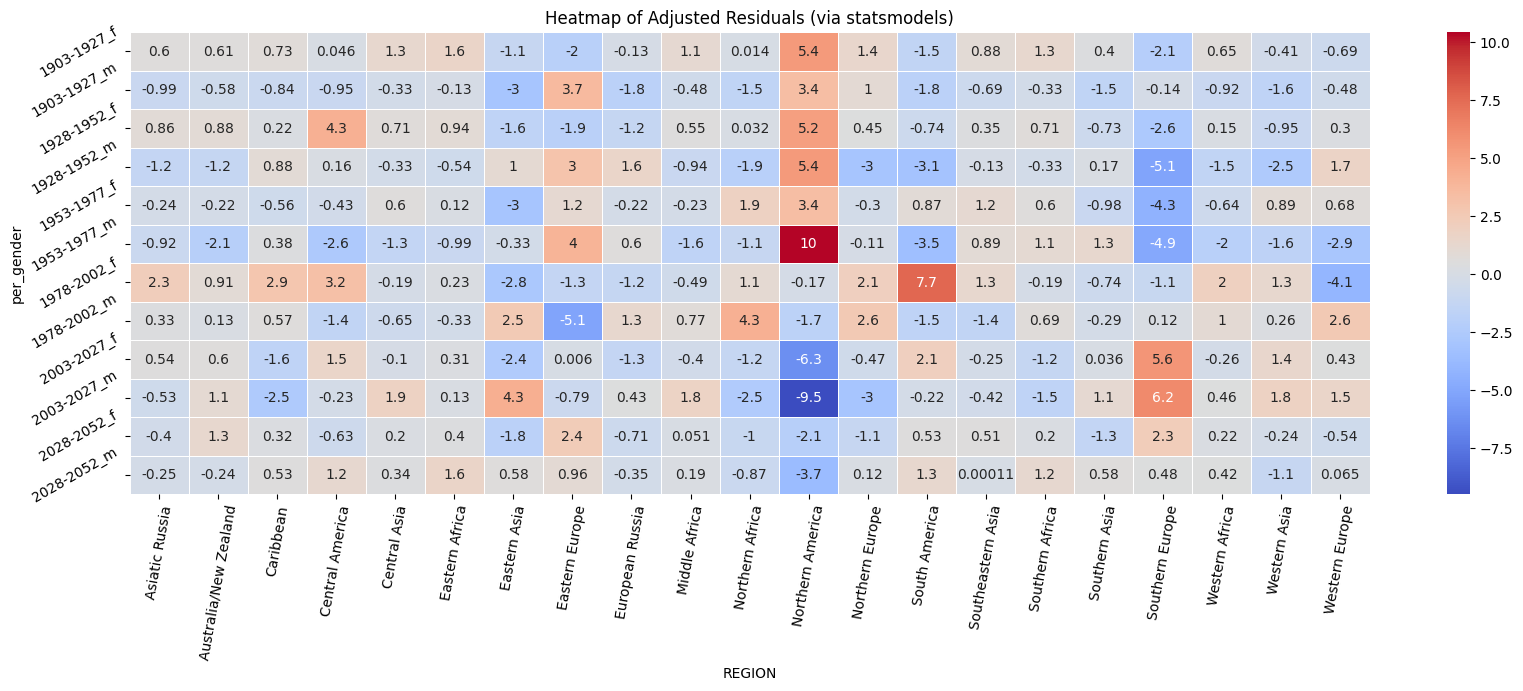

In [52]:
# 1. Create the Table object directly from your data
table = sm.stats.Table(observed)

# 2. Get Adjusted Residuals instantly (no manual formula needed)
adjusted_resids = table.standardized_resids
# 3. Plot
fig, ax = plt.subplots(figsize=(20,6))         
# Sample figsize in inches
ax = sns.heatmap(adjusted_resids, annot=adjusted_resids, cmap="coolwarm", linewidths=.5, ax=ax)
labels = adjusted_resids.index
p = ax.set_yticklabels(labels, rotation=30)
labels_cols = adjusted_resids.columns
p = ax.set_xticklabels(labels_cols, rotation=80)

ax.set_title("Heatmap of Adjusted Residuals (via statsmodels)")
plt.show()

In [53]:
dfs = df_p[(df_p.per_gender.isin(['1978-2002_f']))&(df_p.REGION.isin(['South America']))]
print(len(dfs))

125


In [54]:
dfs.head(10)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,activityYear,periodsActivity,per_gender
2847,http://www.wikidata.org/entity/Q5997330,María Teresa Uribe,1940,female,Pereira,POINT (-75.694558 4.814278),http://www.wikidata.org/entity/Q51111,1931-1940,15,South America,1985,1978-2002,1978-2002_f
2865,http://www.wikidata.org/entity/Q59157058,Maria Cecília de Souza Minayo,1938,female,Itabira,POINT (-43.226944 -19.618889),http://www.wikidata.org/entity/Q1638413,1931-1940,15,South America,1983,1978-2002,1978-2002_f
2902,http://www.wikidata.org/entity/Q6142656,Teresita de Barbieri,1937,female,Montevideo,POINT (-56.191311 -34.905917),http://www.wikidata.org/entity/Q1335,1931-1940,15,South America,1982,1978-2002,1978-2002_f
2965,http://www.wikidata.org/entity/Q56349604,Dulce Consuelo Andreatta Whitaker,1934,female,Curitiba,POINT (-49.271944 -25.429722),http://www.wikidata.org/entity/Q4361,1931-1940,15,South America,1979,1978-2002,1978-2002_f
3065,http://www.wikidata.org/entity/Q9002416,Heleieth Saffioti,1934,female,Ibirá,POINT (-49.240833 -21.08),http://www.wikidata.org/entity/Q1751341,1931-1940,15,South America,1979,1978-2002,1978-2002_f
3123,http://www.wikidata.org/entity/Q66893,Esther Vilar,1935,female,Buenos Aires,POINT (-58.381944 -34.599722),http://www.wikidata.org/entity/Q1486,1931-1940,15,South America,1980,1978-2002,1978-2002_f
3133,http://www.wikidata.org/entity/Q73667712,Suzana Prates,1940,female,Belo Horizonte,POINT (-43.941945 -19.928056),http://www.wikidata.org/entity/Q42800,1931-1940,15,South America,1985,1978-2002,1978-2002_f
3261,http://www.wikidata.org/entity/Q24960821,Jeannette Abouhamad,1934,female,Porlamar,POINT (-63.847778 10.955556),http://www.wikidata.org/entity/Q953449,1931-1940,15,South America,1979,1978-2002,1978-2002_f
3277,http://www.wikidata.org/entity/Q23682004,Dora Barrancos,1940,female,Jacinto Arauz,POINT (-63.433333 -38.066667),http://www.wikidata.org/entity/Q3157094,1931-1940,15,South America,1985,1978-2002,1978-2002_f
3285,http://www.wikidata.org/entity/Q95707177,María Barhoum,1940,female,Libertad,POINT (-56.619167 -34.633333),http://www.wikidata.org/entity/Q946150,1931-1940,15,South America,1985,1978-2002,1978-2002_f


## Personnes inspectées
[María Teresa Uribe](http://www.wikidata.org/entity/Q5997330) (Colombie) et
[Teresita de Barbieri](http://www.wikidata.org/entity/Q6142656) (Uruguay)